## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Configuración de visualización
sns.set_style('darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 2. Carga de Datos

In [2]:
# Cargar el dataset
df = pd.read_csv('../resources/dataset/youtoxic_english_1000.csv')

print(f"✓ Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

✓ Dataset cargado exitosamente
Dimensiones: 1000 filas x 15 columnas


## 3. Exploración Inicial

In [3]:
# Primeras filas
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,"If only people would just take a step back and not make this case about them, because it wasn't ...",False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' banners being held by white cunts is kinda patroniz...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do not like police officers. They are called Crimina...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should have not been shot 6 extra time. Shoot him once if ...",False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB


In [5]:
# Estadísticas descriptivas
df.describe()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,13,997,2,2,2,2,2,2,2,2,2,1,2,1
top,Ugg2KwwX0V8-aXgCoAEC,9pr1oE34bIM,run them over,False,False,False,False,False,False,False,False,False,False,False,False
freq,1,274,3,538,647,979,839,900,862,875,992,999,1000,988,1000


In [6]:
# Columnas del dataset
print("Columnas del dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Columnas del dataset:
1. CommentId
2. VideoId
3. Text
4. IsToxic
5. IsAbusive
6. IsThreat
7. IsProvocative
8. IsObscene
9. IsHatespeech
10. IsRacist
11. IsNationalist
12. IsSexist
13. IsHomophobic
14. IsReligiousHate
15. IsRadicalism


## 4. Análisis de Valores Faltantes

In [7]:
# Valores nulos
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Valores Nulos', ascending=False)

print("\n=== VALORES FALTANTES ===")
print(missing_data[missing_data['Valores Nulos'] > 0])

if missing_data['Valores Nulos'].sum() == 0:
    print("\n✓ No hay valores faltantes en el dataset")


=== VALORES FALTANTES ===
Empty DataFrame
Columns: [Columna, Valores Nulos, Porcentaje (%)]
Index: []

✓ No hay valores faltantes en el dataset


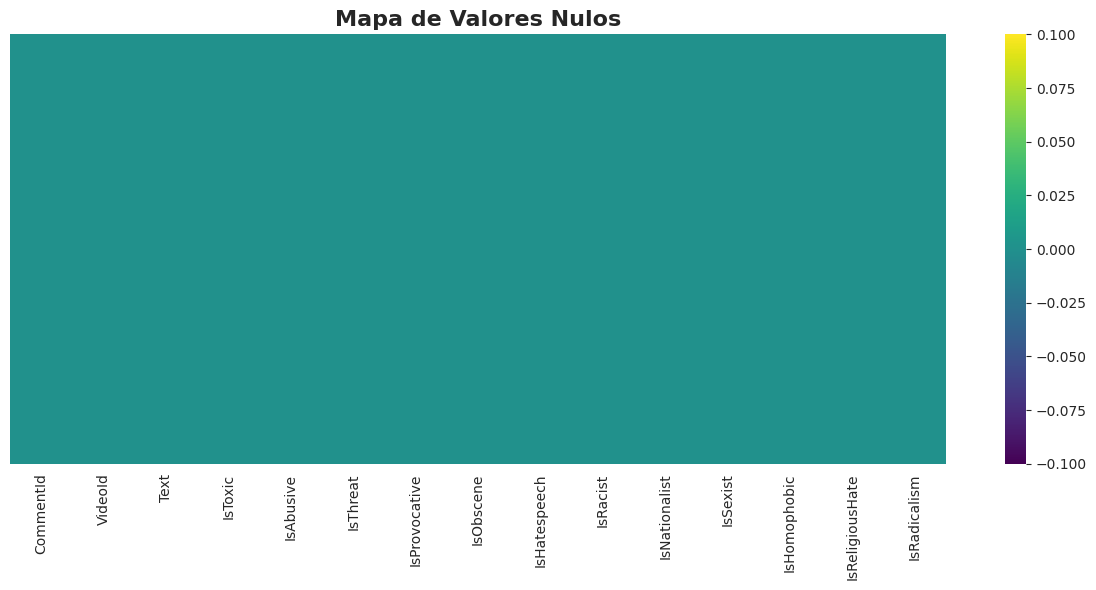

In [8]:
# Visualización de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis de Duplicados

In [9]:
# Duplicados completos
duplicates_total = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicates_total}")

# Duplicados en texto
duplicates_text = df.duplicated(subset=['Text']).sum()
print(f"Textos duplicados: {duplicates_text}")

# Duplicados en CommentId
duplicates_id = df.duplicated(subset=['CommentId']).sum()
print(f"CommentId duplicados: {duplicates_id}")

Filas completamente duplicadas: 0
Textos duplicados: 3
CommentId duplicados: 0


In [10]:
# Ver ejemplos de textos duplicados si existen
if duplicates_text > 0:
    print("\n=== EJEMPLOS DE TEXTOS DUPLICADOS ===")
    duplicate_texts = df[df.duplicated(subset=['Text'], keep=False)].sort_values('Text')
    print(f"Total de registros con texto duplicado: {len(duplicate_texts)}")
    print("\nPrimeros ejemplos:")
    display(duplicate_texts.head(10)[['Text', 'IsToxic', 'IsAbusive', 'IsHatespeech']])


=== EJEMPLOS DE TEXTOS DUPLICADOS ===
Total de registros con texto duplicado: 5

Primeros ejemplos:


,Text,IsToxic,IsAbusive,IsHatespeech
592,RUN THEM OVER,True,True,False
699,RUN THEM OVER,True,True,False
642,run them over,True,True,False
657,run them over,True,True,False
677,run them over,True,True,False


## 6. Análisis del Texto

In [11]:
# Longitud del texto
df['text_length'] = df['Text'].astype(str).apply(len)
df['word_count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

print("\n=== ESTADÍSTICAS DE TEXTO ===")
print(f"Longitud promedio: {df['text_length'].mean():.2f} caracteres")
print(f"Longitud mínima: {df['text_length'].min()} caracteres")
print(f"Longitud máxima: {df['text_length'].max()} caracteres")
print(f"\nPalabras promedio: {df['word_count'].mean():.2f}")
print(f"Palabras mínimas: {df['word_count'].min()}")
print(f"Palabras máximas: {df['word_count'].max()}")


=== ESTADÍSTICAS DE TEXTO ===
Longitud promedio: 185.55 caracteres
Longitud mínima: 3 caracteres
Longitud máxima: 4421 caracteres

Palabras promedio: 33.78
Palabras mínimas: 1
Palabras máximas: 815


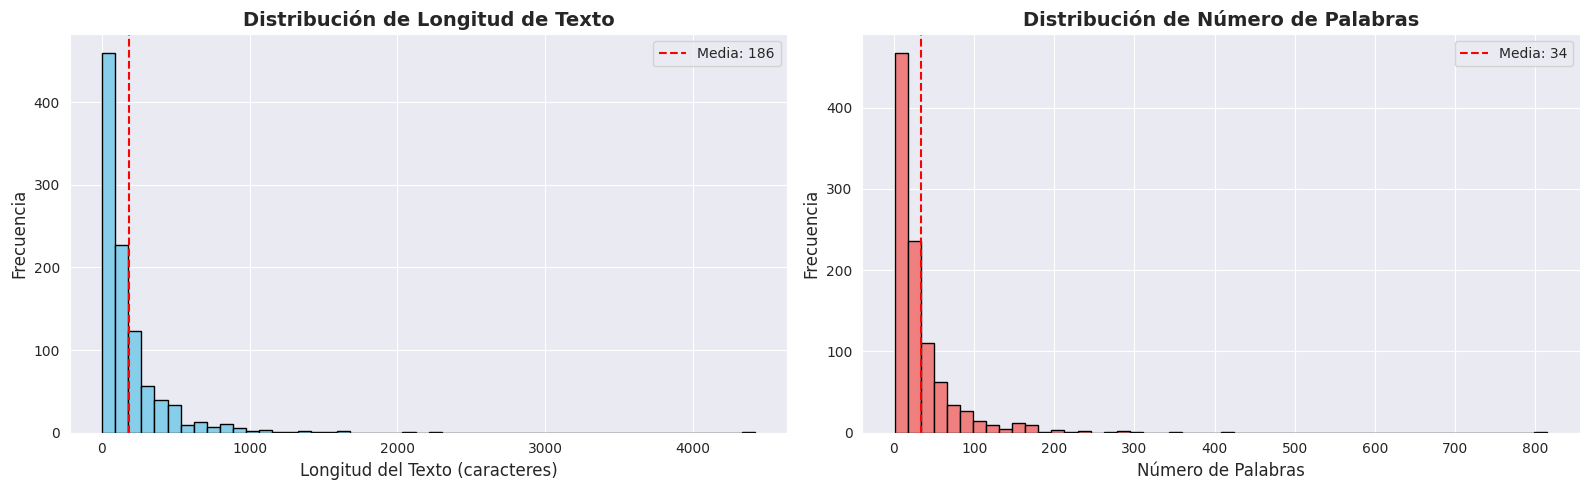

In [12]:
# Distribución de longitud de texto
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Longitud del Texto (caracteres)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Longitud de Texto', fontsize=14, fontweight='bold')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Media: {df["text_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Número de Palabras', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Número de Palabras', fontsize=14, fontweight='bold')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Media: {df["word_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Textos vacíos o muy cortos
empty_texts = df[df['Text'].astype(str).str.strip() == ''].shape[0]
very_short_texts = df[df['word_count'] < 3].shape[0]

print(f"Textos vacíos: {empty_texts}")
print(f"Textos muy cortos (< 3 palabras): {very_short_texts}")

if very_short_texts > 0:
    print("\nEjemplos de textos muy cortos:")
    display(df[df['word_count'] < 3][['Text', 'word_count', 'IsToxic']].head(10))

Textos vacíos: 0
Textos muy cortos (< 3 palabras): 34

Ejemplos de textos muy cortos:


,Text,word_count,IsToxic
105,Wow!!!,1,False
118,CHRISTIANS ROCK!,2,False
131,So ratchet!lol\n,2,False
234,techno party!!!,2,False
243,Perfect police,2,False
244,Protesters suck,2,True
249,"Ah, beautiful.",2,True
303,on drugs*,2,False
342,Nicely done.,2,False
348,Great vid.,2,False


## 7. Análisis de Etiquetas de Toxicidad

In [14]:
# Columnas de etiquetas
label_columns = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 
                 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 
                 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

# Verificar valores únicos en cada columna de etiqueta
print("\n=== VALORES ÚNICOS EN ETIQUETAS ===")
for col in label_columns:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")


=== VALORES ÚNICOS EN ETIQUETAS ===
IsToxic: [False  True]
IsAbusive: [False  True]
IsThreat: [False  True]
IsProvocative: [False  True]
IsObscene: [False  True]
IsHatespeech: [False  True]
IsRacist: [False  True]
IsNationalist: [False  True]
IsSexist: [False  True]
IsHomophobic: [False]
IsReligiousHate: [False  True]
IsRadicalism: [False]


In [15]:
# Convertir valores booleanos a numéricos (si es necesario)
for col in label_columns:
    if col in df.columns:
        df[col] = df[col].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0}).fillna(df[col])

print("✓ Etiquetas convertidas a formato numérico")

✓ Etiquetas convertidas a formato numérico


In [16]:
# Conteo de cada tipo de toxicidad
toxicity_counts = {}
for col in label_columns:
    if col in df.columns:
        toxicity_counts[col] = df[col].sum()

toxicity_df = pd.DataFrame({
    'Tipo': list(toxicity_counts.keys()),
    'Cantidad': list(toxicity_counts.values()),
    'Porcentaje': [f"{(v/len(df)*100):.2f}%" for v in toxicity_counts.values()]
}).sort_values('Cantidad', ascending=False)

print("\n=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD ===")
display(toxicity_df)


=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD ===


,Tipo,Cantidad,Porcentaje
0,IsToxic,462,46.20%
1,IsAbusive,353,35.30%
3,IsProvocative,161,16.10%
5,IsHatespeech,138,13.80%
6,IsRacist,125,12.50%
4,IsObscene,100,10.00%
2,IsThreat,21,2.10%
10,IsReligiousHate,12,1.20%
7,IsNationalist,8,0.80%
8,IsSexist,1,0.10%


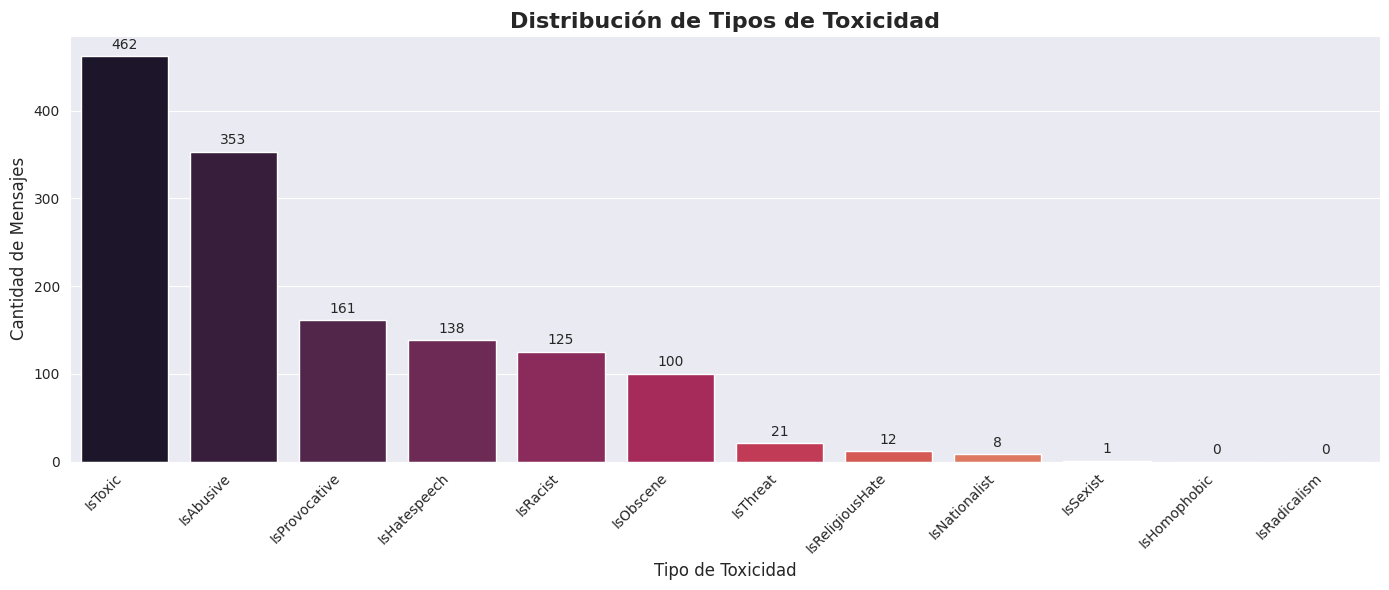

In [17]:
# Visualización de tipos de toxicidad
plt.figure(figsize=(14, 6))
sns.barplot(data=toxicity_df, x='Tipo', y='Cantidad', hue='Tipo', palette='rocket', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Tipos de Toxicidad', fontsize=16, fontweight='bold')
plt.ylabel('Cantidad de Mensajes', fontsize=12)
plt.xlabel('Tipo de Toxicidad', fontsize=12)

# Añadir valores en las barras
for i, v in enumerate(toxicity_df['Cantidad']):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
# Balance de clases (Tóxico vs No Tóxico)
toxic_count = df['IsToxic'].sum()
non_toxic_count = len(df) - toxic_count

print(f"\n=== BALANCE DE CLASES ===")
print(f"Mensajes Tóxicos: {toxic_count} ({toxic_count/len(df)*100:.2f}%)")
print(f"Mensajes No Tóxicos: {non_toxic_count} ({non_toxic_count/len(df)*100:.2f}%)")
print(f"\nRatio Tóxico/No Tóxico: 1:{non_toxic_count/toxic_count:.2f}")


=== BALANCE DE CLASES ===
Mensajes Tóxicos: 462 (46.20%)
Mensajes No Tóxicos: 538 (53.80%)

Ratio Tóxico/No Tóxico: 1:1.16


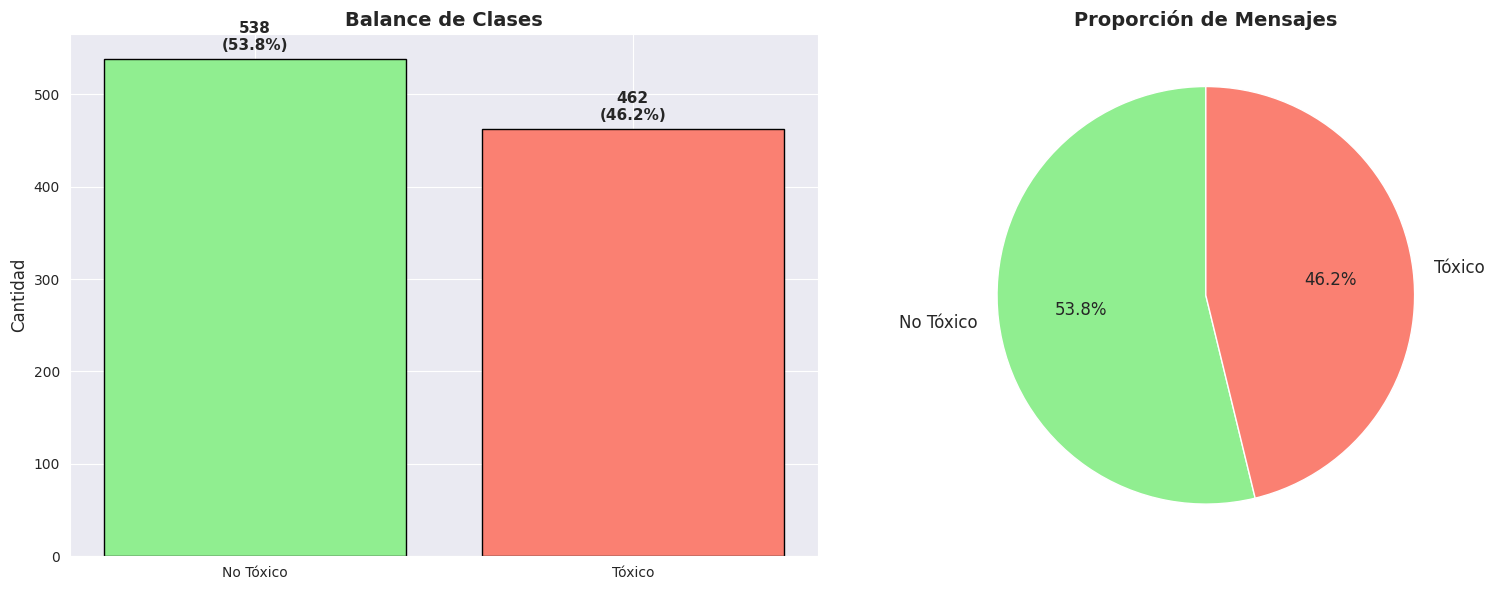

In [19]:
# Gráfico de balance de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
axes[0].bar(['No Tóxico', 'Tóxico'], [non_toxic_count, toxic_count], 
            color=['lightgreen', 'salmon'], edgecolor='black')
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].set_title('Balance de Clases', fontsize=14, fontweight='bold')
axes[0].text(0, non_toxic_count + 10, f'{non_toxic_count}\n({non_toxic_count/len(df)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')
axes[0].text(1, toxic_count + 10, f'{toxic_count}\n({toxic_count/len(df)*100:.1f}%)', 
             ha='center', fontsize=11, fontweight='bold')

# Gráfico de pastel
axes[1].pie([non_toxic_count, toxic_count], labels=['No Tóxico', 'Tóxico'], 
            autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Mensajes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Correlación entre Tipos de Toxicidad

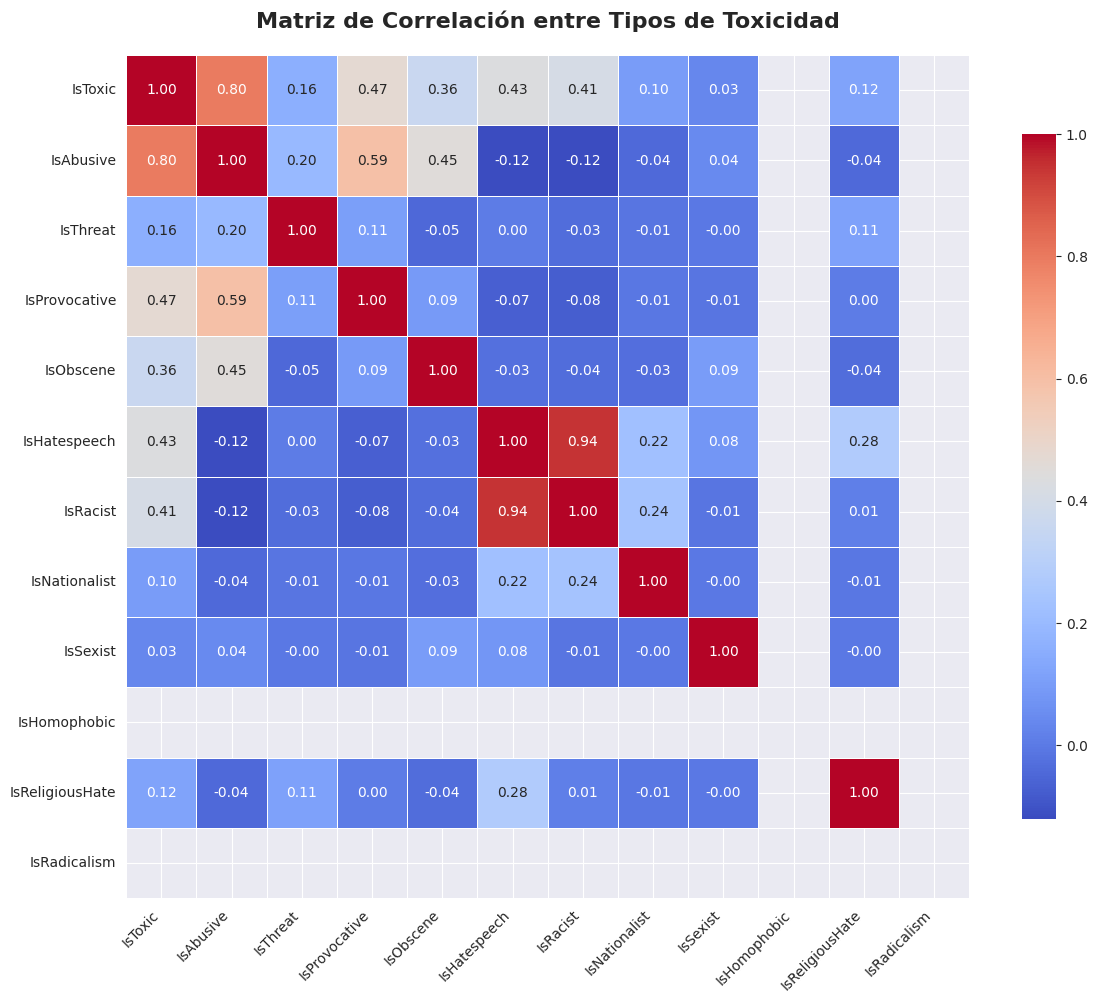

In [20]:
# Matriz de correlación
correlation_matrix = df[label_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Tipos de Toxicidad', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Co-ocurrencia de etiquetas
print("\n=== CO-OCURRENCIA DE ETIQUETAS ===")
print("Mensajes con múltiples etiquetas de toxicidad:")

df['num_labels'] = df[label_columns].sum(axis=1)
multi_label_counts = df['num_labels'].value_counts().sort_index()

for num, count in multi_label_counts.items():
    print(f"  {int(num)} etiquetas: {count} mensajes ({count/len(df)*100:.2f}%)")


=== CO-OCURRENCIA DE ETIQUETAS ===
Mensajes con múltiples etiquetas de toxicidad:
  0 etiquetas: 538 mensajes (53.80%)
  2 etiquetas: 100 mensajes (10.00%)
  3 etiquetas: 294 mensajes (29.40%)
  4 etiquetas: 47 mensajes (4.70%)
  5 etiquetas: 15 mensajes (1.50%)
  6 etiquetas: 6 mensajes (0.60%)


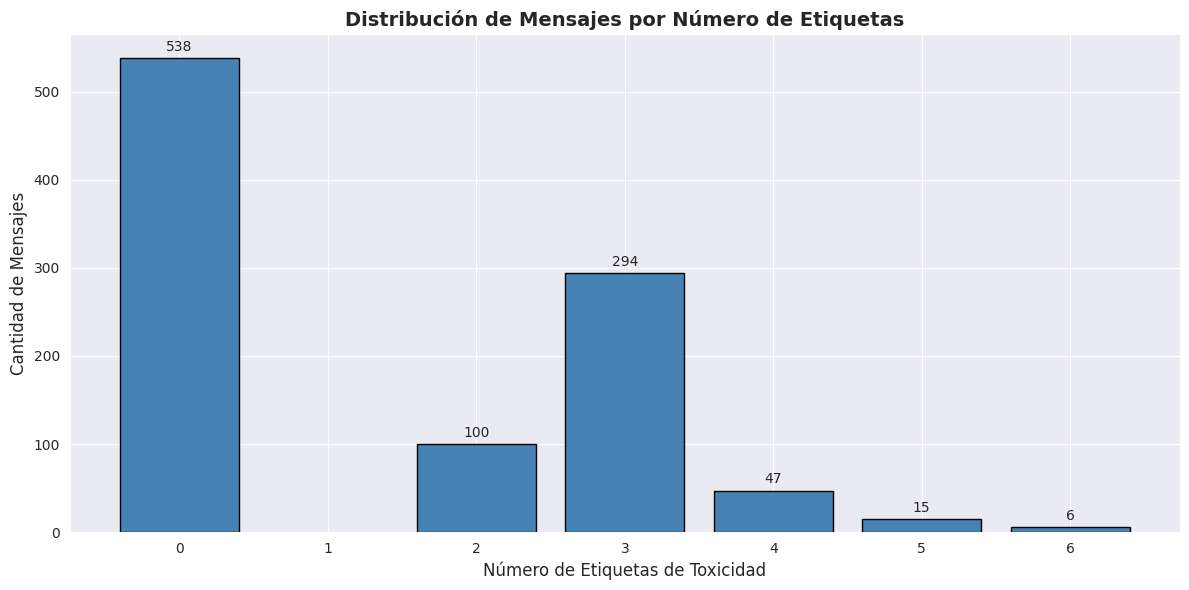

In [22]:
# Visualizar distribución de múltiples etiquetas
plt.figure(figsize=(12, 6))
plt.bar(multi_label_counts.index, multi_label_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Número de Etiquetas de Toxicidad', fontsize=12)
plt.ylabel('Cantidad de Mensajes', fontsize=12)
plt.title('Distribución de Mensajes por Número de Etiquetas', fontsize=14, fontweight='bold')
plt.xticks(range(int(df['num_labels'].max()) + 1))

for i, v in enumerate(multi_label_counts.values):
    plt.text(multi_label_counts.index[i], v + 5, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Análisis de Texto por Categoría

In [23]:
# Comparar longitud de texto entre mensajes tóxicos y no tóxicos
toxic_texts = df[df['IsToxic'] == 1]
non_toxic_texts = df[df['IsToxic'] == 0]

print("\n=== COMPARACIÓN DE LONGITUD DE TEXTO ===")
print(f"Mensajes Tóxicos:")
print(f"  - Longitud promedio: {toxic_texts['text_length'].mean():.2f} caracteres")
print(f"  - Palabras promedio: {toxic_texts['word_count'].mean():.2f}")
print(f"\nMensajes No Tóxicos:")
print(f"  - Longitud promedio: {non_toxic_texts['text_length'].mean():.2f} caracteres")
print(f"  - Palabras promedio: {non_toxic_texts['word_count'].mean():.2f}")


=== COMPARACIÓN DE LONGITUD DE TEXTO ===
Mensajes Tóxicos:
  - Longitud promedio: 189.39 caracteres
  - Palabras promedio: 34.60

Mensajes No Tóxicos:
  - Longitud promedio: 182.26 caracteres
  - Palabras promedio: 33.07


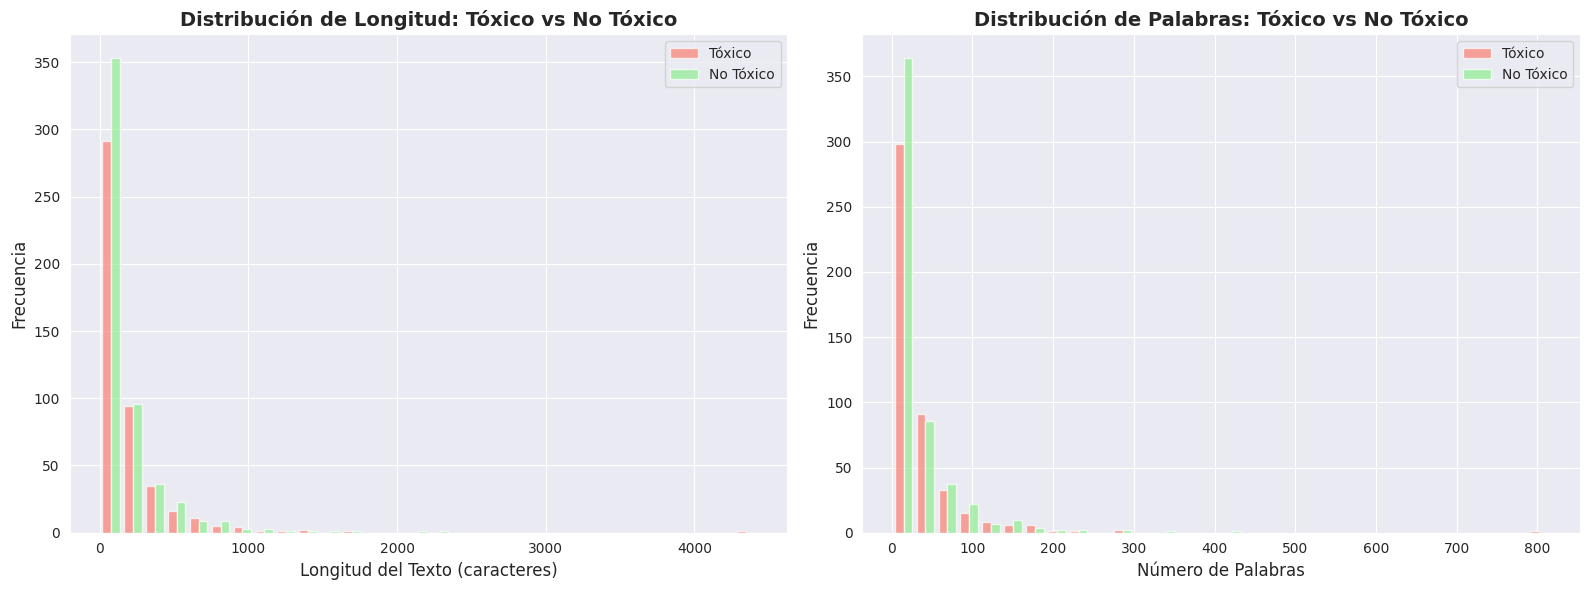

In [24]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Longitud de caracteres
axes[0].hist([toxic_texts['text_length'], non_toxic_texts['text_length']], 
             bins=30, label=['Tóxico', 'No Tóxico'], color=['salmon', 'lightgreen'], alpha=0.7)
axes[0].set_xlabel('Longitud del Texto (caracteres)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Longitud: Tóxico vs No Tóxico', fontsize=14, fontweight='bold')
axes[0].legend()

# Número de palabras
axes[1].hist([toxic_texts['word_count'], non_toxic_texts['word_count']], 
             bins=30, label=['Tóxico', 'No Tóxico'], color=['salmon', 'lightgreen'], alpha=0.7)
axes[1].set_xlabel('Número de Palabras', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Palabras: Tóxico vs No Tóxico', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Análisis de Caracteres Especiales

In [25]:
# Detectar patrones en el texto
df['has_urls'] = df['Text'].astype(str).str.contains(r'http[s]?://|www\.', case=False, regex=True)
df['has_mentions'] = df['Text'].astype(str).str.contains(r'@\w+', regex=True)
df['has_hashtags'] = df['Text'].astype(str).str.contains(r'#\w+', regex=True)
df['has_emojis'] = df['Text'].astype(str).str.contains(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF]', regex=True)
df['exclamation_count'] = df['Text'].astype(str).str.count('!')
df['question_count'] = df['Text'].astype(str).str.count('\\?')
df['uppercase_ratio'] = df['Text'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

print("\n=== ANÁLISIS DE CARACTERÍSTICAS DEL TEXTO ===")
print(f"Mensajes con URLs: {df['has_urls'].sum()} ({df['has_urls'].sum()/len(df)*100:.2f}%)")
print(f"Mensajes con menciones (@): {df['has_mentions'].sum()} ({df['has_mentions'].sum()/len(df)*100:.2f}%)")
print(f"Mensajes con hashtags (#): {df['has_hashtags'].sum()} ({df['has_hashtags'].sum()/len(df)*100:.2f}%)")
print(f"Mensajes con emojis: {df['has_emojis'].sum()} ({df['has_emojis'].sum()/len(df)*100:.2f}%)")
print(f"\nPromedio de signos de exclamación: {df['exclamation_count'].mean():.2f}")
print(f"Promedio de signos de interrogación: {df['question_count'].mean():.2f}")
print(f"Ratio promedio de mayúsculas: {df['uppercase_ratio'].mean():.2%}")


=== ANÁLISIS DE CARACTERÍSTICAS DEL TEXTO ===
Mensajes con URLs: 12 (1.20%)
Mensajes con menciones (@): 5 (0.50%)
Mensajes con hashtags (#): 9 (0.90%)
Mensajes con emojis: 6 (0.60%)

Promedio de signos de exclamación: 0.36
Promedio de signos de interrogación: 0.29
Ratio promedio de mayúsculas: 5.28%


In [26]:
# Comparar características entre mensajes tóxicos y no tóxicos
# Actualizar las variables después de añadir las nuevas columnas
toxic_texts = df[df['IsToxic'] == 1]
non_toxic_texts = df[df['IsToxic'] == 0]

comparison_features = ['exclamation_count', 'question_count', 'uppercase_ratio']

print("\n=== COMPARACIÓN DE CARACTERÍSTICAS: TÓXICO VS NO TÓXICO ===")
for feature in comparison_features:
    toxic_mean = toxic_texts[feature].mean()
    non_toxic_mean = non_toxic_texts[feature].mean()
    print(f"\n{feature}:")
    print(f"  - Tóxico: {toxic_mean:.4f}")
    print(f"  - No Tóxico: {non_toxic_mean:.4f}")
    print(f"  - Diferencia: {abs(toxic_mean - non_toxic_mean):.4f}")


=== COMPARACIÓN DE CARACTERÍSTICAS: TÓXICO VS NO TÓXICO ===

exclamation_count:
  - Tóxico: 0.4177
  - No Tóxico: 0.3104
  - Diferencia: 0.1073

question_count:
  - Tóxico: 0.2835
  - No Tóxico: 0.3011
  - Diferencia: 0.0176

uppercase_ratio:
  - Tóxico: 0.0561
  - No Tóxico: 0.0500
  - Diferencia: 0.0061


## 11. Limpieza del Dataset

### 10.1 Análisis Detallado de Textos Cortos

In [27]:
# Analizar textos cortos en detalle
short_texts = df[df['word_count'] < 3].copy()

print(f"=== ANÁLISIS DETALLADO DE TEXTOS CORTOS ===" )
print(f"Total de textos con menos de 3 palabras: {len(short_texts)}\n")

# Separar por categoría de toxicidad
short_toxic = short_texts[short_texts['IsToxic'] == 1]
short_non_toxic = short_texts[short_texts['IsToxic'] == 0]

print(f"Textos cortos TÓXICOS: {len(short_toxic)} ({len(short_toxic)/len(short_texts)*100:.1f}%)")
print(f"Textos cortos NO TÓXICOS: {len(short_non_toxic)} ({len(short_non_toxic)/len(short_texts)*100:.1f}%)")

# Mostrar todos los textos cortos organizados
print(f"\n{'='*80}")
print("TODOS LOS TEXTOS CORTOS:")
print(f"{'='*80}\n")

for idx, row in short_texts.iterrows():
    toxicity = "🔴 TÓXICO" if row['IsToxic'] == 1 else "🟢 NO TÓXICO"
    labels = [col.replace('Is', '') for col in label_columns if row.get(col, 0) == 1]
    label_str = f" [{', '.join(labels)}]" if labels else ""
    
    print(f"{idx}. {toxicity} | Palabras: {row['word_count']} | \"{row['Text']}\"{label_str}")

# Estadísticas adicionales
print(f"\n{'='*80}")
print("RESUMEN POR LONGITUD:")
print(f"{'='*80}")
word_count_dist = short_texts.groupby('word_count').agg({
    'Text': 'count',
    'IsToxic': 'sum'
}).rename(columns={'Text': 'Total', 'IsToxic': 'Tóxicos'})
word_count_dist['No Tóxicos'] = word_count_dist['Total'] - word_count_dist['Tóxicos']
word_count_dist['% Tóxicos'] = (word_count_dist['Tóxicos'] / word_count_dist['Total'] * 100).round(1)

print(word_count_dist)

=== ANÁLISIS DETALLADO DE TEXTOS CORTOS ===
Total de textos con menos de 3 palabras: 34

Textos cortos TÓXICOS: 12 (35.3%)
Textos cortos NO TÓXICOS: 22 (64.7%)

TODOS LOS TEXTOS CORTOS:

105. 🟢 NO TÓXICO | Palabras: 1 | "Wow!!!"
118. 🟢 NO TÓXICO | Palabras: 2 | "CHRISTIANS ROCK!"
131. 🟢 NO TÓXICO | Palabras: 2 | "So ratchet!lol
"
234. 🟢 NO TÓXICO | Palabras: 2 | "techno party!!!"
243. 🟢 NO TÓXICO | Palabras: 2 | "Perfect police"
244. 🔴 TÓXICO | Palabras: 2 | "Protesters suck" [Toxic, Abusive, Obscene]
249. 🔴 TÓXICO | Palabras: 2 | "Ah, beautiful." [Toxic, Abusive, Provocative]
303. 🟢 NO TÓXICO | Palabras: 2 | "on drugs*"
342. 🟢 NO TÓXICO | Palabras: 2 | "Nicely done."
348. 🟢 NO TÓXICO | Palabras: 2 | "Great vid."
353. 🟢 NO TÓXICO | Palabras: 2 | "@12:25 LMFAO"
433. 🟢 NO TÓXICO | Palabras: 1 | "wtf"
516. 🟢 NO TÓXICO | Palabras: 2 | "Thank you"
531. 🟢 NO TÓXICO | Palabras: 2 | "MERICA !!!"
545. 🟢 NO TÓXICO | Palabras: 2 | "Great interviews"
548. 🔴 TÓXICO | Palabras: 2 | "Vile cunt" [Toxi

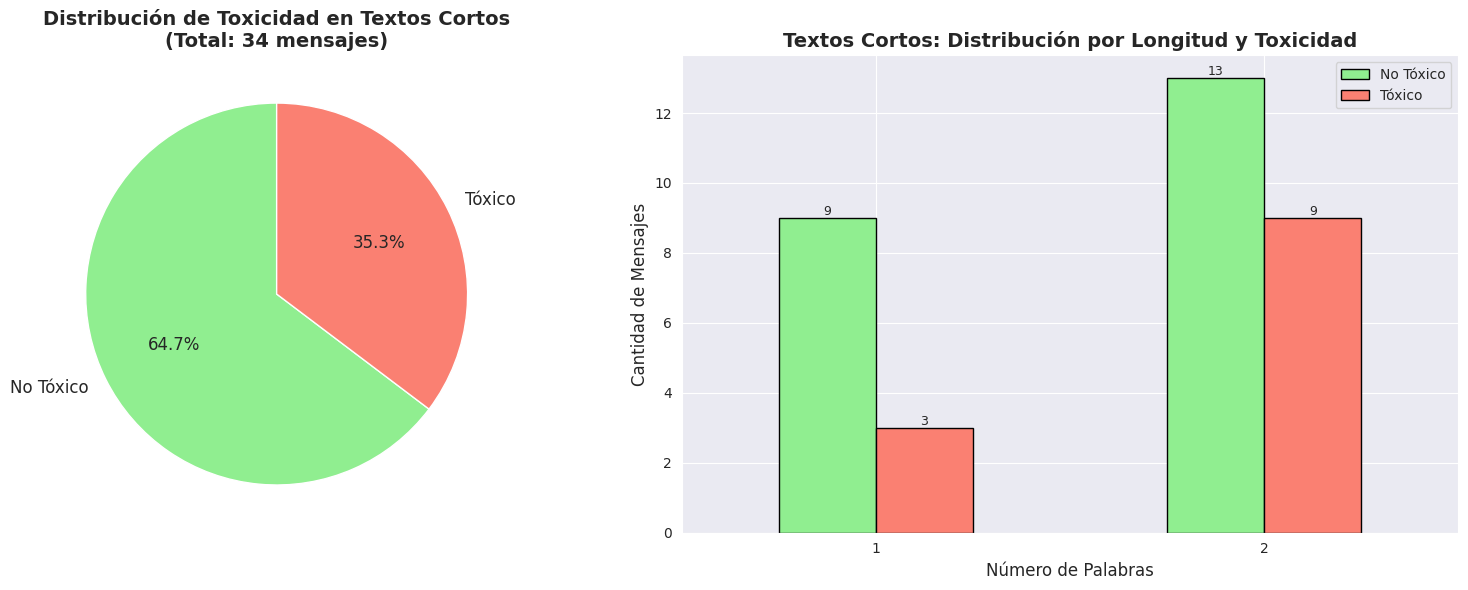


ANÁLISIS DE PATRONES:

📊 Mensajes cortos TÓXICOS más comunes:
   • "Protesters suck" → 1 veces
   • "Ah, beautiful." → 1 veces
   • "Vile cunt" → 1 veces
   • "Rich brats" → 1 veces
   • "Idiots" → 1 veces
   • "Idiotz" → 1 veces
   • "Stupid niggers" → 1 veces
   • "Stupid American" → 1 veces
   • "#blacklivesdontmatter" → 1 veces
   • "dumb mf" → 1 veces

📊 Mensajes cortos NO TÓXICOS más comunes:
   • "Wow!!!" → 1 veces
   • "CHRISTIANS ROCK!" → 1 veces
   • "So ratchet!lol
" → 1 veces
   • "techno party!!!" → 1 veces
   • "Perfect police" → 1 veces
   • "on drugs*" → 1 veces
   • "Nicely done." → 1 veces
   • "Great vid." → 1 veces
   • "@12:25 LMFAO" → 1 veces
   • "wtf" → 1 veces


In [28]:
# Visualización de textos cortos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución de textos cortos por toxicidad
toxicity_short = short_texts['IsToxic'].value_counts()
colors_pie = ['lightgreen', 'salmon']
axes[0].pie([len(short_non_toxic), len(short_toxic)], 
            labels=['No Tóxico', 'Tóxico'],
            autopct='%1.1f%%', 
            colors=colors_pie,
            startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title(f'Distribución de Toxicidad en Textos Cortos\n(Total: {len(short_texts)} mensajes)', 
                  fontsize=14, fontweight='bold')

# Gráfico 2: Distribución por número de palabras
word_count_data = short_texts.groupby(['word_count', 'IsToxic']).size().unstack(fill_value=0)
word_count_data.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'], edgecolor='black')
axes[1].set_xlabel('Número de Palabras', fontsize=12)
axes[1].set_ylabel('Cantidad de Mensajes', fontsize=12)
axes[1].set_title('Textos Cortos: Distribución por Longitud y Toxicidad', fontsize=14, fontweight='bold')
axes[1].legend(['No Tóxico', 'Tóxico'], fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Añadir valores en las barras
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

# Análisis de patrones en textos cortos
print(f"\n{'='*80}")
print("ANÁLISIS DE PATRONES:")
print(f"{'='*80}")

# Palabras más comunes en textos cortos tóxicos
print("\n📊 Mensajes cortos TÓXICOS más comunes:")
toxic_short_counts = short_toxic['Text'].value_counts().head(10)
for text, count in toxic_short_counts.items():
    print(f"   • \"{text}\" → {count} veces")

# Palabras más comunes en textos cortos no tóxicos
print("\n📊 Mensajes cortos NO TÓXICOS más comunes:")
non_toxic_short_counts = short_non_toxic['Text'].value_counts().head(10)
for text, count in non_toxic_short_counts.items():
    print(f"   • \"{text}\" → {count} veces")

### 10.2 Decisión sobre Textos Cortos

Basándote en el análisis anterior, ahora puedes decidir qué textos cortos eliminar.

**Opciones disponibles:**
1. No eliminar ningún texto corto (mantener todos)
2. Eliminar solo textos de 1 palabra (12 mensajes)
3. Eliminar textos < 2 palabras (12 mensajes con 1 palabra)
4. Eliminar textos < 3 palabras (34 mensajes - opción original)
5. Eliminar solo textos cortos específicos (lista personalizada)

In [29]:
# Identificar textos neutrales/interjecciones sin valor analítico
print("=== IDENTIFICACIÓN DE TEXTOS NEUTRALES/INTERJECCIONES ===\n")

# Analizar textos cortos NO tóxicos que son neutrales
textos_neutrales_candidatos = short_non_toxic.copy()

print(f"📋 Todos los textos cortos NO TÓXICOS ({len(textos_neutrales_candidatos)} mensajes):\n")
for idx, row in textos_neutrales_candidatos.iterrows():
    print(f"   • \"{row['Text']}\" ({row['word_count']} palabra/s)")

# Lista sugerida de textos neutrales para eliminar
textos_neutrales_eliminar = [
    "Wow!!!",
    "wtf",
    "on drugs*",
    "techno party!!!",
    "@12:25 LMFAO",
    "So ratchet!lol\n"
]

print(f"\n\n💡 SUGERENCIA - Textos neutrales/interjecciones para eliminar:")
print("   (expresiones sin valor analítico para detección de odio)\n")
for texto in textos_neutrales_eliminar:
    if texto in textos_neutrales_candidatos['Text'].values:
        print(f"   ✓ \"{texto}\"")
    else:
        print(f"   ✗ \"{texto}\" (no encontrado)")

print(f"\n\n📊 Textos NO TÓXICOS que SÍ tienen valor (se mantendrán):")
textos_con_valor = textos_neutrales_candidatos[~textos_neutrales_candidatos['Text'].isin(textos_neutrales_eliminar)]
for idx, row in textos_con_valor.iterrows():
    print(f"   • \"{row['Text']}\" - tiene contenido relevante")

print(f"\n\n📌 RESUMEN:")
print(f"   Total textos cortos no tóxicos: {len(textos_neutrales_candidatos)}")
print(f"   Interjecciones/neutrales a eliminar: {len([t for t in textos_neutrales_eliminar if t in textos_neutrales_candidatos['Text'].values])}")
print(f"   Textos con valor a mantener: {len(textos_con_valor)}")

=== IDENTIFICACIÓN DE TEXTOS NEUTRALES/INTERJECCIONES ===

📋 Todos los textos cortos NO TÓXICOS (22 mensajes):

   • "Wow!!!" (1 palabra/s)
   • "CHRISTIANS ROCK!" (2 palabra/s)
   • "So ratchet!lol
" (2 palabra/s)
   • "techno party!!!" (2 palabra/s)
   • "Perfect police" (2 palabra/s)
   • "on drugs*" (2 palabra/s)
   • "Nicely done." (2 palabra/s)
   • "Great vid." (2 palabra/s)
   • "@12:25 LMFAO" (2 palabra/s)
   • "wtf" (1 palabra/s)
   • "Thank you" (2 palabra/s)
   • "MERICA !!!" (2 palabra/s)
   • "Great interviews" (2 palabra/s)
   • "#alllivesmatter" (1 palabra/s)
   • "Wow..........." (1 palabra/s)
   • "Respect!" (1 palabra/s)
   • "Awesome women." (2 palabra/s)
   • "Bravo!" (1 palabra/s)
   • "GOOD " (1 palabra/s)
   • "Darude...............sand...storm......." (1 palabra/s)
   • "ignorant" (1 palabra/s)
   • "Dats tuff" (2 palabra/s)


💡 SUGERENCIA - Textos neutrales/interjecciones para eliminar:
   (expresiones sin valor analítico para detección de odio)

   ✓ "Wow!!!"

In [30]:
# CONFIGURACIÓN: Elige qué textos cortos eliminar
# Cambia el valor de 'opcion_limpieza' según tu decisión

opcion_limpieza = 1  # Cambiar este número según lo que quieras hacer

print("=== OPCIONES DE LIMPIEZA PARA TEXTOS CORTOS ===\n")
print("1. No eliminar ningún texto corto (mantener todos)")
print("2. Eliminar solo textos de 1 palabra")
print("3. Eliminar textos con menos de 2 palabras")
print("4. Eliminar textos con menos de 3 palabras (opción original)")
print("5. Eliminar textos específicos (lista personalizada)")

print(f"\n✅ Opción seleccionada: {opcion_limpieza}")

# Textos específicos que podrías querer eliminar (opción 5)
textos_a_eliminar = [
    "Wow!!!",
    "wtf",
    "on drugs*"
]

# Visualizar qué se eliminará según la opción
if opcion_limpieza == 1:
    textos_eliminados = []
    print("\n➡️ NO se eliminarán textos cortos")
    
elif opcion_limpieza == 2:
    textos_eliminados = short_texts[short_texts['word_count'] == 1]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos de 1 palabra:")
    for idx, row in textos_eliminados.iterrows():
        toxicity = "🔴" if row['IsToxic'] == 1 else "🟢"
        print(f"   {toxicity} \"{row['Text']}\"")
        
elif opcion_limpieza == 3:
    textos_eliminados = short_texts[short_texts['word_count'] < 2]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos con < 2 palabras:")
    for idx, row in textos_eliminados.iterrows():
        toxicity = "🔴" if row['IsToxic'] == 1 else "🟢"
        print(f"   {toxicity} \"{row['Text']}\"")
        
elif opcion_limpieza == 4:
    textos_eliminados = short_texts[short_texts['word_count'] < 3]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos con < 3 palabras (todos los cortos)")
    
elif opcion_limpieza == 5:
    textos_eliminados = short_texts[short_texts['Text'].isin(textos_a_eliminar)]
    print(f"\n➡️ Se eliminarán {len(textos_eliminados)} textos específicos:")
    for idx, row in textos_eliminados.iterrows():
        toxicity = "🔴" if row['IsToxic'] == 1 else "🟢"
        print(f"   {toxicity} \"{row['Text']}\"")
    print(f"\n💡 Edita la lista 'textos_a_eliminar' para personalizar")

print(f"\n📊 Resumen:")
print(f"   Total de textos cortos: {len(short_texts)}")
print(f"   Textos que se eliminarán: {len(textos_eliminados) if opcion_limpieza > 1 else 0}")
print(f"   Textos cortos que se mantendrán: {len(short_texts) - (len(textos_eliminados) if opcion_limpieza > 1 else 0)}")

=== OPCIONES DE LIMPIEZA PARA TEXTOS CORTOS ===

1. No eliminar ningún texto corto (mantener todos)
2. Eliminar solo textos de 1 palabra
3. Eliminar textos con menos de 2 palabras
4. Eliminar textos con menos de 3 palabras (opción original)
5. Eliminar textos específicos (lista personalizada)

✅ Opción seleccionada: 1

➡️ NO se eliminarán textos cortos

📊 Resumen:
   Total de textos cortos: 34
   Textos que se eliminarán: 0
   Textos cortos que se mantendrán: 34


In [31]:
# Crear una copia para limpieza
df_clean = df.copy()

print("=== PROCESO DE LIMPIEZA ===")
print(f"Tamaño inicial: {len(df_clean)} registros\n")

# 1. Eliminar duplicados basados en texto
initial_size = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Text'], keep='first')
removed_duplicates = initial_size - len(df_clean)
print(f"✓ Duplicados eliminados: {removed_duplicates}")

# 2. Eliminar textos vacíos
initial_size = len(df_clean)
df_clean = df_clean[df_clean['Text'].astype(str).str.strip() != '']
removed_empty = initial_size - len(df_clean)
print(f"✓ Textos vacíos eliminados: {removed_empty}")

# 3. Eliminar textos neutrales/interjecciones sin valor analítico
textos_neutrales_eliminar = [
    "Wow!!!",
    "wtf",
    "on drugs*",
    "techno party!!!",
    "@12:25 LMFAO",
    "So ratchet!lol\n"
]

initial_size = len(df_clean)
df_clean = df_clean[~df_clean['Text'].isin(textos_neutrales_eliminar)]
removed_neutrals = initial_size - len(df_clean)
print(f"✓ Textos neutrales/interjecciones eliminados: {removed_neutrals}")

# 4. Resetear índice
df_clean = df_clean.reset_index(drop=True)

print(f"\n=== RESULTADO FINAL ===")
print(f"Tamaño final: {len(df_clean)} registros")
print(f"Registros eliminados: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

=== PROCESO DE LIMPIEZA ===
Tamaño inicial: 1000 registros

✓ Duplicados eliminados: 3
✓ Textos vacíos eliminados: 0
✓ Textos neutrales/interjecciones eliminados: 6

=== RESULTADO FINAL ===
Tamaño final: 991 registros
Registros eliminados: 9 (0.90%)


## 12. Verificación Post-Limpieza

In [32]:
# Verificar balance después de la limpieza
toxic_clean = df_clean['IsToxic'].sum()
non_toxic_clean = len(df_clean) - toxic_clean

print("\n=== BALANCE POST-LIMPIEZA ===")
print(f"Mensajes Tóxicos: {toxic_clean} ({toxic_clean/len(df_clean)*100:.2f}%)")
print(f"Mensajes No Tóxicos: {non_toxic_clean} ({non_toxic_clean/len(df_clean)*100:.2f}%)")
print(f"Ratio: 1:{non_toxic_clean/toxic_clean:.2f}")


=== BALANCE POST-LIMPIEZA ===
Mensajes Tóxicos: 459 (46.32%)
Mensajes No Tóxicos: 532 (53.68%)
Ratio: 1:1.16


In [33]:
# Distribución de etiquetas después de la limpieza
toxicity_counts_clean = {}
for col in label_columns:
    if col in df_clean.columns:
        toxicity_counts_clean[col] = df_clean[col].sum()

toxicity_df_clean = pd.DataFrame({
    'Tipo': list(toxicity_counts_clean.keys()),
    'Cantidad': list(toxicity_counts_clean.values()),
    'Porcentaje': [f"{(v/len(df_clean)*100):.2f}%" for v in toxicity_counts_clean.values()]
}).sort_values('Cantidad', ascending=False)

print("\n=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD (POST-LIMPIEZA) ===")
display(toxicity_df_clean)


=== DISTRIBUCIÓN DE TIPOS DE TOXICIDAD (POST-LIMPIEZA) ===


,Tipo,Cantidad,Porcentaje
0,IsToxic,459,46.32%
1,IsAbusive,350,35.32%
3,IsProvocative,158,15.94%
5,IsHatespeech,138,13.93%
6,IsRacist,125,12.61%
4,IsObscene,100,10.09%
2,IsThreat,21,2.12%
10,IsReligiousHate,12,1.21%
7,IsNationalist,8,0.81%
8,IsSexist,1,0.10%


## 13. Ejemplos de Mensajes

In [34]:
# Ejemplos de mensajes no tóxicos
print("\n=== EJEMPLOS DE MENSAJES NO TÓXICOS ===")
non_toxic_samples = df_clean[df_clean['IsToxic'] == 0].sample(min(5, len(df_clean[df_clean['IsToxic'] == 0])))
for i, row in non_toxic_samples.iterrows():
    print(f"\n{i+1}. {row['Text'][:200]}..." if len(row['Text']) > 200 else f"\n{i+1}. {row['Text']}")


=== EJEMPLOS DE MENSAJES NO TÓXICOS ===

147. criminal kids get shot by the police almost everyday. Plus Mike Brown has a bad criminal record and started the fight.

344. All this info being put out about Mike Brown-why is nobody bringing up the fact Off Darrin Wilson tested positive for (illegal,mood altering,non prescription) steroids in his post shooting toxicology ...

850. Crimes committed during a Riot should become a Federal Offence.  The Federal Government has the ability to build unlimited prisons.

676. This is where the gas grenades, pepper spray and knight stick would be applied

493. Omg when he started rapping I lost it. Lmao


In [35]:
# Ejemplos de mensajes tóxicos
print("\n=== EJEMPLOS DE MENSAJES TÓXICOS ===")
toxic_samples = df_clean[df_clean['IsToxic'] == 1].sample(min(5, len(df_clean[df_clean['IsToxic'] == 1])))
for i, row in toxic_samples.iterrows():
    labels = [col.replace('Is', '') for col in label_columns if row.get(col, 0) == 1]
    print(f"\n{i+1}. {row['Text'][:200]}..." if len(row['Text']) > 200 else f"\n{i+1}. {row['Text']}")
    print(f"   Etiquetas: {', '.join(labels)}")


=== EJEMPLOS DE MENSAJES TÓXICOS ===

129. Wow, an a-hole that makes a CNN interviewer seem reasonable and balanced....
   Etiquetas: Toxic, Abusive, Obscene

700. Drive through them
   Etiquetas: Toxic, Abusive, Provocative

607. Useless people standing in the middle of the road screaming useless shit.
   Etiquetas: Toxic, Abusive, Obscene

621. Anyone else pissed off about how it ended?
Just let them walk off, no big deal. All the crap that they just pulled and no one got pepper sprayed
   Etiquetas: Toxic, Abusive, Obscene

31. stop being criminals and you wont get shot, that simple
   Etiquetas: Toxic, Abusive, Provocative


## 14. Guardar Dataset Limpio

In [36]:
# Seleccionar columnas relevantes para el dataset limpio
columns_to_save = ['CommentId', 'VideoId', 'Text'] + label_columns
df_final = df_clean[columns_to_save].copy()

# Guardar el dataset limpio
output_path = '../resources/dataset/youtoxic_english_1000_clean.csv'
df_final.to_csv(output_path, index=False)

print(f"✓ Dataset limpio guardado en: {output_path}")
print(f"Dimensiones finales: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")

✓ Dataset limpio guardado en: ../resources/dataset/youtoxic_english_1000_clean.csv
Dimensiones finales: 991 filas x 15 columnas


## 15. Resumen del EDA

In [37]:
print("="*80)
print("                    RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("="*80)
print(f"\n📊 DATASET ORIGINAL:")
print(f"   - Total de registros: {len(df)}")
print(f"   - Mensajes tóxicos: {df['IsToxic'].sum()} ({df['IsToxic'].sum()/len(df)*100:.2f}%)")
print(f"   - Mensajes no tóxicos: {len(df) - df['IsToxic'].sum()} ({(len(df) - df['IsToxic'].sum())/len(df)*100:.2f}%)")

print(f"\n🧹 LIMPIEZA REALIZADA:")
print(f"   - Duplicados eliminados: {removed_duplicates}")
print(f"   - Textos vacíos eliminados: {removed_empty}")
print(f"   - Textos neutrales/interjecciones eliminados: {removed_neutrals}")
print(f"   - Total eliminado: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

print(f"\n✅ DATASET LIMPIO:")
print(f"   - Total de registros: {len(df_clean)}")
print(f"   - Mensajes tóxicos: {toxic_clean} ({toxic_clean/len(df_clean)*100:.2f}%)")
print(f"   - Mensajes no tóxicos: {non_toxic_clean} ({non_toxic_clean/len(df_clean)*100:.2f}%)")
print(f"   - Longitud promedio: {df_clean['text_length'].mean():.2f} caracteres")
print(f"   - Palabras promedio: {df_clean['word_count'].mean():.2f}")

print(f"\n📁 ARCHIVO GUARDADO:")
print(f"   - Ubicación: {output_path}")
print(f"   - Columnas: {len(df_final.columns)}")

print("\n" + "="*80)
print("✨ EDA completado exitosamente!")
print("="*80)

                    RESUMEN DEL ANÁLISIS EXPLORATORIO

📊 DATASET ORIGINAL:
   - Total de registros: 1000
   - Mensajes tóxicos: 462 (46.20%)
   - Mensajes no tóxicos: 538 (53.80%)

🧹 LIMPIEZA REALIZADA:
   - Duplicados eliminados: 3
   - Textos vacíos eliminados: 0
   - Textos neutrales/interjecciones eliminados: 6
   - Total eliminado: 9 (0.90%)

✅ DATASET LIMPIO:
   - Total de registros: 991
   - Mensajes tóxicos: 459 (46.32%)
   - Mensajes no tóxicos: 532 (53.68%)
   - Longitud promedio: 187.14 caracteres
   - Palabras promedio: 34.06

📁 ARCHIVO GUARDADO:
   - Ubicación: ../resources/dataset/youtoxic_english_1000_clean.csv
   - Columnas: 15

✨ EDA completado exitosamente!


# 5. Entrenamiento del Modelo con TF-IDF + SVM

Dado que tenemos ~1000 registros (dataset pequeño), usaremos TF-IDF con SVM, que es una combinación excelente para este tipo de datos. Optimizaremos los hiperparámetros con Optuna.

In [38]:
# Importar librerías necesarias
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import optuna
from optuna.samplers import TPESampler
import joblib
import warnings
warnings.filterwarnings('ignore')

/home/noe/Documentos/IA-F5-Proyecto/proyecto10-grupo5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5.1 Preparación de los datos

In [39]:
# Preparar X (textos) e y (etiqueta de toxicidad)
X = df['Text'].values
y = df['IsToxic'].values

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset completo: {len(X)} muestras")
print(f"Training set: {len(X_train)} muestras")
print(f"Test set: {len(X_test)} muestras")
print(f"\nDistribución en training:")
print(f"  No tóxico: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Tóxico: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)")

Dataset completo: 1000 muestras
Training set: 800 muestras
Test set: 200 muestras

Distribución en training:
  No tóxico: 430 (53.8%)
  Tóxico: 370 (46.2%)


## 5.2 Optimización de hiperparámetros con Optuna

Vamos a optimizar los hiperparámetros del TF-IDF y del SVM usando Optuna para encontrar la mejor combinación.

In [40]:
def objective(trial):
    """
    Función objetivo para Optuna que optimiza hiperparámetros de TF-IDF y SVM
    """
    # Hiperparámetros de TF-IDF
    max_features = trial.suggest_int('max_features', 1000, 10000, step=1000)
    ngram_range_max = trial.suggest_int('ngram_range_max', 1, 3)
    min_df = trial.suggest_int('min_df', 1, 5)
    max_df = trial.suggest_float('max_df', 0.5, 1.0)
    
    # Hiperparámetros de SVM
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])
    
    # Crear vectorizador TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, ngram_range_max),
        min_df=min_df,
        max_df=max_df,
        stop_words='english'
    )
    
    # Transformar datos
    X_train_tfidf = vectorizer.fit_transform(X_train)
    
    # Crear y entrenar modelo SVM
    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        random_state=42,
        max_iter=2000
    )
    
    # Cross-validation con F1-score (mejor para datos desbalanceados)
    scores = cross_val_score(
        model, X_train_tfidf, y_train, 
        cv=5, scoring='f1', n_jobs=-1
    )
    
    return scores.mean()

# Crear estudio de Optuna
print("Iniciando optimización con Optuna...")
print("Esto puede tomar varios minutos...\n")

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

# Ejecutar optimización
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*80)
print("OPTIMIZACIÓN COMPLETADA")
print("="*80)
print(f"Mejor F1-score: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-26 12:19:28,791] A new study created in memory with name: no-name-881b90b6-4e2a-469c-9511-b0285b41752d


Iniciando optimización con Optuna...
Esto puede tomar varios minutos...



Best trial: 0. Best value: 0.6654:   2%|▏         | 1/50 [00:01<01:09,  1.42s/it]

[I 2025-11-26 12:19:30,205] Trial 0 finished with value: 0.6653995709955975 and parameters: {'max_features': 4000, 'ngram_range_max': 3, 'min_df': 4, 'max_df': 0.7993292420985183, 'C': 0.02938027938703535, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6653995709955975.


Best trial: 0. Best value: 0.6654:   4%|▍         | 2/50 [00:02<01:00,  1.26s/it]

...

[I 2025-11-26 12:19:34,539] Trial 35 finished with value: 0.6669028035974014 and parameters: {'max_features': 8000, 'ngram_range_max': 2, 'min_df': 4, 'max_df': 0.7509535891616768, 'C': 0.05843072009024037, 'class_weight': 'balanced'}. Best is trial 21 with value: 0.6737447958647749.
[I 2025-11-26 12:19:34,583] Trial 36 finished with value: 0.6776667122803335 and parameters: {'max_features': 8000, 'ngram_range_max': 1, 'min_df': 5, 'max_df': 0.6203762085876314, 'C': 0.193386104967546, 'class_weight': 'balanced'}. Best is trial 36 with value: 0.6776667122803335.
[I 2025-11-26 12:19:34,626] Trial 37 finished with value: 0.6793920521199989 and parameters: {'max_features': 8000, 'ngram_range_max': 1, 'min_df': 5, 'max_df': 0.6146846539458756, 'C': 0.17466886554939023, 'class_weight': 'balanced'}. Best is trial 37 with value: 0.6793920521199989.
[I 2025-11-26 12:19:34,667] Trial 38 finished with value: 0.6372376937731268 and parameters: {'max_features': 7000, 'ngram_range_max': 1, 'min_df':

Best trial: 44. Best value: 0.687516:  88%|████████▊ | 44/50 [00:06<00:00, 19.82it/s]

[I 2025-11-26 12:19:34,758] Trial 40 finished with value: 0.6478655313054803 and parameters: {'max_features': 7000, 'ngram_range_max': 1, 'min_df': 4, 'max_df': 0.543875686210475, 'C': 0.1491798996633915, 'class_weight': None}. Best is trial 37 with value: 0.6793920521199989.
[I 2025-11-26 12:19:34,801] Trial 41 finished with value: 0.6749391312168201 and parameters: {'max_features': 9000, 'ngram_range_max': 1, 'min_df': 5, 'max_df': 0.6225432038369827, 'C': 0.22476684810179892, 'class_weight': 'balanced'}. Best is trial 37 with value: 0.6793920521199989.
[I 2025-11-26 12:19:34,844] Trial 42 finished with value: 0.672161944039675 and parameters: {'max_features': 9000, 'ngram_range_max': 1, 'min_df': 5, 'max_df': 0.6254816639762203, 'C': 0.269534801669161, 'class_weight': 'balanced'}. Best is trial 37 with value: 0.6793920521199989.
[I 2025-11-26 12:19:34,886] Trial 43 finished with value: 0.6793920521199989 and parameters: {'max_features': 8000, 'ngram_range_max': 1, 'min_df': 5, 'max_

Best trial: 44. Best value: 0.687516: 100%|██████████| 50/50 [00:06<00:00,  7.87it/s]

[I 2025-11-26 12:19:34,976] Trial 45 finished with value: 0.6466918472122819 and parameters: {'max_features': 9000, 'ngram_range_max': 1, 'min_df': 5, 'max_df': 0.6349614510707648, 'C': 0.4046911814856844, 'class_weight': None}. Best is trial 44 with value: 0.687516485234097.
[I 2025-11-26 12:19:35,020] Trial 46 finished with value: 0.6713946969064772 and parameters: {'max_features': 9000, 'ngram_range_max': 1, 'min_df': 4, 'max_df': 0.550475426989606, 'C': 0.1729985115451222, 'class_weight': 'balanced'}. Best is trial 44 with value: 0.687516485234097.
[I 2025-11-26 12:19:35,062] Trial 47 finished with value: 0.6382688814575224 and parameters: {'max_features': 7000, 'ngram_range_max': 1, 'min_df': 5, 'max_df': 0.5895594014083284, 'C': 0.7840058885686135, 'class_weight': 'balanced'}. Best is trial 44 with value: 0.687516485234097.
[I 2025-11-26 12:19:35,105] Trial 48 finished with value: 0.6653793382430322 and parameters: {'max_features': 8000, 'ngram_range_max': 1, 'min_df': 1, 'max_df

## 5.3 Entrenamiento del modelo final

Ahora entrenaremos el modelo con los mejores hiperparámetros encontrados.

In [41]:
# Extraer mejores parámetros
best_params = study.best_params

# Crear vectorizador final con mejores parámetros
vectorizer_final = TfidfVectorizer(
    max_features=best_params['max_features'],
    ngram_range=(1, best_params['ngram_range_max']),
    min_df=best_params['min_df'],
    max_df=best_params['max_df'],
    stop_words='english'
)

# Transformar datos de entrenamiento y test
X_train_tfidf = vectorizer_final.fit_transform(X_train)
X_test_tfidf = vectorizer_final.transform(X_test)

# Crear y entrenar modelo final
model_final = LinearSVC(
    C=best_params['C'],
    class_weight=best_params['class_weight'],
    random_state=42,
    max_iter=2000
)

print("Entrenando modelo final...")
model_final.fit(X_train_tfidf, y_train)
print("✓ Modelo entrenado exitosamente!")

Entrenando modelo final...
✓ Modelo entrenado exitosamente!


## 5.4 Evaluación del modelo

Evaluaremos el rendimiento del modelo en el conjunto de test.

In [42]:
# Predicciones
y_pred = model_final.predict(X_test_tfidf)
y_pred_train = model_final.predict(X_train_tfidf)

# Calcular métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("="*80)
print("EVALUACIÓN DEL MODELO")
print("="*80)
print("\n📊 MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO:")
print(f"  Accuracy:  {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_pred_train):.4f}")

print("\n📊 MÉTRICAS EN CONJUNTO DE TEST:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")

print("\n" + "="*80)
print("CLASSIFICATION REPORT (Test Set)")
print("="*80)
print(classification_report(y_test, y_pred, target_names=['No Tóxico', 'Tóxico']))

EVALUACIÓN DEL MODELO

📊 MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO:
  Accuracy:  0.8700
  Precision: 0.8736
  Recall:    0.8405
  F1-Score:  0.8567

📊 MÉTRICAS EN CONJUNTO DE TEST:
  Accuracy:  0.7300
  Precision: 0.7317
  Recall:    0.6522
  F1-Score:  0.6897

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

   No Tóxico       0.73      0.80      0.76       108
      Tóxico       0.73      0.65      0.69        92

    accuracy                           0.73       200
   macro avg       0.73      0.72      0.73       200
weighted avg       0.73      0.73      0.73       200



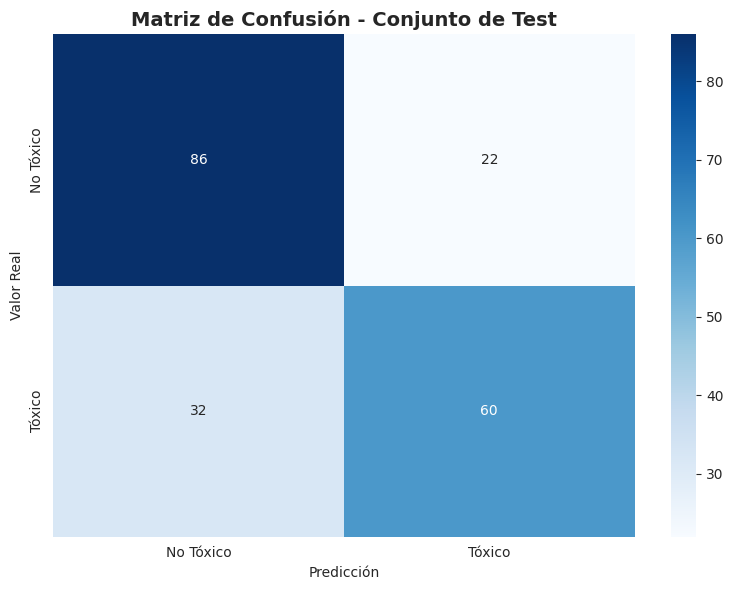


Interpretación de la Matriz de Confusión:
  True Negatives (TN):  86 - Correctamente clasificados como No Tóxicos
  False Positives (FP): 22 - Incorrectamente clasificados como Tóxicos
  False Negatives (FN): 32 - Incorrectamente clasificados como No Tóxicos
  True Positives (TP):  60 - Correctamente clasificados como Tóxicos


In [43]:
# Matriz de confusión
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Tóxico', 'Tóxico'],
            yticklabels=['No Tóxico', 'Tóxico'])
plt.title('Matriz de Confusión - Conjunto de Test', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print("\nInterpretación de la Matriz de Confusión:")
print(f"  True Negatives (TN):  {cm[0,0]} - Correctamente clasificados como No Tóxicos")
print(f"  False Positives (FP): {cm[0,1]} - Incorrectamente clasificados como Tóxicos")
print(f"  False Negatives (FN): {cm[1,0]} - Incorrectamente clasificados como No Tóxicos")
print(f"  True Positives (TP):  {cm[1,1]} - Correctamente clasificados como Tóxicos")

## 5.5 Análisis de palabras más importantes

Veamos qué características (palabras/n-gramas) son más importantes para la clasificación.

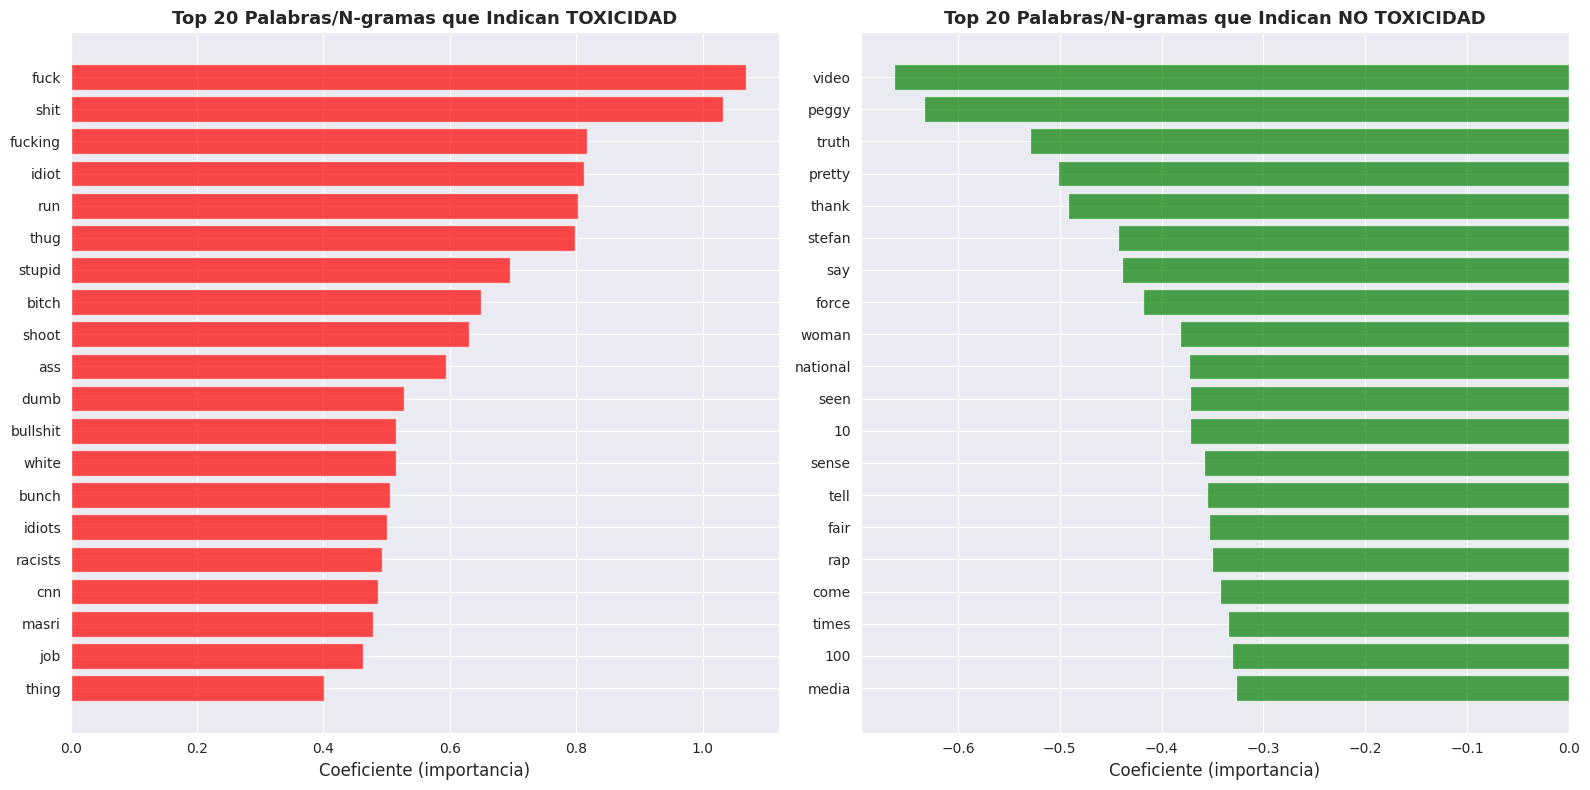

Top 10 indicadores de TOXICIDAD:
  'fuck': 1.0680
  'shit': 1.0324
  'fucking': 0.8173
  'idiot': 0.8120
  'run': 0.8033
  'thug': 0.7977
  'stupid': 0.6957
  'bitch': 0.6499
  'shoot': 0.6297
  'ass': 0.5943

Top 10 indicadores de NO TOXICIDAD:
  'video': -0.6625
  'peggy': -0.6329
  'truth': -0.5291
  'pretty': -0.5013
  'thank': -0.4920
  'stefan': -0.4428
  'say': -0.4386
  'force': -0.4180
  'woman': -0.3816
  'national': -0.3733


In [44]:
# Obtener coeficientes del modelo y nombres de características
feature_names = vectorizer_final.get_feature_names_out()
coefficients = model_final.coef_[0]

# Crear DataFrame con características y sus coeficientes
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Top 20 palabras que indican TOXICIDAD (coeficientes positivos más altos)
top_toxic = feature_importance.nlargest(20, 'coefficient')

# Top 20 palabras que indican NO TOXICIDAD (coeficientes negativos más bajos)
top_non_toxic = feature_importance.nsmallest(20, 'coefficient')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Palabras tóxicas
axes[0].barh(range(len(top_toxic)), top_toxic['coefficient'].values, color='red', alpha=0.7)
axes[0].set_yticks(range(len(top_toxic)))
axes[0].set_yticklabels(top_toxic['feature'].values)
axes[0].set_xlabel('Coeficiente (importancia)', fontsize=12)
axes[0].set_title('Top 20 Palabras/N-gramas que Indican TOXICIDAD', 
                  fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Palabras no tóxicas
axes[1].barh(range(len(top_non_toxic)), top_non_toxic['coefficient'].values, color='green', alpha=0.7)
axes[1].set_yticks(range(len(top_non_toxic)))
axes[1].set_yticklabels(top_non_toxic['feature'].values)
axes[1].set_xlabel('Coeficiente (importancia)', fontsize=12)
axes[1].set_title('Top 20 Palabras/N-gramas que Indican NO TOXICIDAD', 
                  fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 indicadores de TOXICIDAD:")
for idx, row in top_toxic.head(10).iterrows():
    print(f"  '{row['feature']}': {row['coefficient']:.4f}")

print("\nTop 10 indicadores de NO TOXICIDAD:")
for idx, row in top_non_toxic.head(10).iterrows():
    print(f"  '{row['feature']}': {row['coefficient']:.4f}")

## 5.6 Pruebas con ejemplos

Probemos el modelo con algunos ejemplos para ver cómo funciona en la práctica.

In [ ]:
# Función para predecir toxicidad
def predict_toxicity(text):
    """
    Predice si un texto es tóxico o no
    """
    text_tfidf = vectorizer_final.transform([text])
    prediction = model_final.predict(text_tfidf)[0]
    
    # Obtener score de decisión (confianza)
    decision = model_final.decision_function(text_tfidf)[0]
    
    return {
        'text': text,
        'prediction': 'TÓXICO' if prediction == 1 else 'NO TÓXICO',
        'confidence': abs(decision)
    }

# Ejemplos de prueba
test_examples = [
    "This is a great video, thank you for sharing!",
    "You are an idiot and should shut up",
    "I disagree with your opinion, but I respect it",
    "Fuck you and your stupid ideas",
    "This is interesting, I learned something new",
    "You're a waste of space, nobody likes you"
]

print("="*80)
print("PRUEBAS CON EJEMPLOS")
print("="*80)

for i, example in enumerate(test_examples, 1):
    result = predict_toxicity(example)
    print(f"\n{i}. Texto: '{result['text']}'")
    print(f"   Predicción: {result['prediction']}")
    print(f"   Confianza: {result['confidence']:.4f}")

PRUEBAS CON EJEMPLOS

1. Texto: 'This is a great video, thank you for sharing!'
   Predicción: NO TÓXICO
   Confianza: 0.9171

2. Texto: 'You are an idiot and should shut up'
   Predicción: TÓXICO
   Confianza: 0.6955

3. Texto: 'I disagree with your opinion, but I respect it'
   Predicción: NO TÓXICO
   Confianza: 0.2022

4. Texto: 'Fuck you and your stupid ideas'
   Predicción: TÓXICO
   Confianza: 1.1156

5. Texto: 'This is interesting, I learned something new'
   Predicción: NO TÓXICO
   Confianza: 0.3406

6. Texto: 'You're a waste of space, nobody likes you'
   Predicción: NO TÓXICO
   Confianza: 0.1165


## 5.7 Guardar el modelo

Guardaremos el modelo entrenado y el vectorizador para usarlos posteriormente.

In [46]:
# Crear directorio para modelos si no existe
import os
models_dir = '../backend/models'
os.makedirs(models_dir, exist_ok=True)

# Guardar modelo y vectorizador
model_path = os.path.join(models_dir, 'svm_toxicity_model.pkl')
vectorizer_path = os.path.join(models_dir, 'tfidf_vectorizer.pkl')

joblib.dump(model_final, model_path)
joblib.dump(vectorizer_final, vectorizer_path)

print("✓ Modelo guardado exitosamente!")
print(f"  - Modelo: {model_path}")
print(f"  - Vectorizador: {vectorizer_path}")

# Guardar también los mejores hiperparámetros
import json
params_path = os.path.join(models_dir, 'best_hyperparameters.json')
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=4)
print(f"  - Hiperparámetros: {params_path}")

# Guardar métricas de evaluación
metrics = {
    'test_accuracy': float(accuracy_score(y_test, y_pred)),
    'test_precision': float(precision_score(y_test, y_pred)),
    'test_recall': float(recall_score(y_test, y_pred)),
    'test_f1': float(f1_score(y_test, y_pred)),
    'train_accuracy': float(accuracy_score(y_train, y_pred_train)),
    'train_f1': float(f1_score(y_train, y_pred_train))
}

metrics_path = os.path.join(models_dir, 'model_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"  - Métricas: {metrics_path}")

✓ Modelo guardado exitosamente!
  - Modelo: ../backend/models/svm_toxicity_model.pkl
  - Vectorizador: ../backend/models/tfidf_vectorizer.pkl
  - Hiperparámetros: ../backend/models/best_hyperparameters.json
  - Métricas: ../backend/models/model_metrics.json


## 5.8 Resumen del modelo

Resumen final del modelo entrenado y su rendimiento.

In [47]:
print("="*80)
print("RESUMEN DEL MODELO ENTRENADO")
print("="*80)

print("\n🎯 ARQUITECTURA:")
print("  - Vectorización: TF-IDF")
print("  - Algoritmo: Linear SVM (LinearSVC)")
print(f"  - Características: {X_train_tfidf.shape[1]:,}")

print("\n⚙️ HIPERPARÁMETROS ÓPTIMOS:")
for key, value in best_params.items():
    print(f"  - {key}: {value}")

print("\n📊 RENDIMIENTO:")
print(f"  Training Set:")
print(f"    • Accuracy: {metrics['train_accuracy']:.4f}")
print(f"    • F1-Score: {metrics['train_f1']:.4f}")
print(f"  Test Set:")
print(f"    • Accuracy:  {metrics['test_accuracy']:.4f}")
print(f"    • Precision: {metrics['test_precision']:.4f}")
print(f"    • Recall:    {metrics['test_recall']:.4f}")
print(f"    • F1-Score:  {metrics['test_f1']:.4f}")

print("\n💾 ARCHIVOS GUARDADOS:")
print(f"  - {model_path}")
print(f"  - {vectorizer_path}")
print(f"  - {params_path}")
print(f"  - {metrics_path}")

print("\n✅ Modelo listo para uso en producción!")
print("="*80)

RESUMEN DEL MODELO ENTRENADO

🎯 ARQUITECTURA:
  - Vectorización: TF-IDF
  - Algoritmo: Linear SVM (LinearSVC)
  - Características: 545

⚙️ HIPERPARÁMETROS ÓPTIMOS:
  - max_features: 9000
  - ngram_range_max: 1
  - min_df: 5
  - max_df: 0.6347113779556238
  - C: 0.11762123848818869
  - class_weight: balanced

📊 RENDIMIENTO:
  Training Set:
    • Accuracy: 0.8700
    • F1-Score: 0.8567
  Test Set:
    • Accuracy:  0.7300
    • Precision: 0.7317
    • Recall:    0.6522
    • F1-Score:  0.6897

💾 ARCHIVOS GUARDADOS:
  - ../backend/models/svm_toxicity_model.pkl
  - ../backend/models/tfidf_vectorizer.pkl
  - ../backend/models/best_hyperparameters.json
  - ../backend/models/model_metrics.json

✅ Modelo listo para uso en producción!
